We used ChatGPT5 as a reference on how to perform various data analysis tasks in Python and as a partial source of reference information. We are responsible for the content and quality of the submitted work.


## 1. Import Required Libraries

In [175]:
# EDA tools
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(10)
import warnings
warnings.filterwarnings("ignore")

#Single model classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

#Ensemble classifications models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#Model evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics._scorer import _SCORERS
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report, roc_auc_score,f1_score, recall_score, precision_score, average_precision_score,
make_scorer, precision_recall_curve)
from sklearn.utils.class_weight import compute_sample_weight
import time

# Imbalance, Hyperparameter tunning and pipelines
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import pickle


## 2. Exploratory Data Analysis and Data Preparation


In [176]:
#Load the file into a pandas data frame.
data = pd.read_csv("diabetes.csv")
#Get structural information of the data set.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [177]:
#Visualize first 5 rows of data of the first 12 columns.
data.head().iloc[:,:12]

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN


In [178]:
#Visualize first 5 rows of data of the remaining columns.
data.head().iloc[:,12:]

,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,41,0,1,0,0,0,250.83,NaN,NaN,1,...,No,No,No,No,No,No,No,No,No,NO
1,59,0,18,0,0,0,276,250.01,255,9,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,11,5,13,2,0,1,648,250,V27,6,...,No,No,No,No,No,No,No,No,Yes,NO
3,44,1,16,0,0,0,8,250.43,403,7,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,51,0,8,0,0,0,197,157,250,5,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [179]:
#Look for missing values.
print(data.isna().sum().sort_values(ascending=False))

weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
encounter_id                    0
troglitazone                    0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
citoglipton                     0
tolazamide                      0
examide                         0
glipizide                       0
insulin                         0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-pioglitazone          0
change                          0
diabetesMed                     0
glyburide                       0
repaglinide   

Based on the above, the following columns have high missing proportions:
- weight (96.9% missing)
- max_glu_serum (94.7% missing)
- A1Cresult (83.3% missing)
- medical_specialty (49.1% missing)
- payer_code (39.6% missing)

They can therefore be removed. 

In [180]:
#Do data preprocessing on missing values
cols_to_drop = ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code']
data = data.drop(columns=cols_to_drop)
data.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [181]:
data.nunique().sort_values(ascending = True)

citoglipton                      1
examide                          1
diabetesMed                      2
change                           2
metformin-pioglitazone           2
acetohexamide                    2
metformin-rosiglitazone          2
glimepiride-pioglitazone         2
glipizide-metformin              2
tolbutamide                      2
troglitazone                     2
readmitted                       3
gender                           3
tolazamide                       3
insulin                          4
miglitol                         4
acarbose                         4
rosiglitazone                    4
pioglitazone                     4
glyburide-metformin              4
glyburide                        4
glipizide                        4
glimepiride                      4
chlorpropamide                   4
repaglinide                      4
metformin                        4
nateglinide                      4
race                             5
num_procedures      

Based on the above EDA analysis, 'citoglipton' and 'examide' have only one unique value. They can therefore be removed. 

In [182]:
# Remove columns with only one unique value
data = data.drop(columns=['citoglipton', 'examide'])
data.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


For the "race" column, which is a categorical feature and already includes an "Other" category, we will assign all missing values to "Other"

In [183]:

data['race'] = data['race'].fillna('Other')

For the columns "diag_1", "diag_2", and "diag_3", although they are defined as categorical features in the original dataset, EDA shows that each of them contains over 700 unique categories. Therefore, it is no longer appropriate to treat them as categorical variables. Since these columns are represented by ICD9 codes, which are typically continuous numbers ranging from 0 to 999 (each corresponding to a specific diagnosis), it is more appropriate to convert them into numerical features. Additionally, as a special mapping, codes that start with 'E' or 'V' will be uniformly mapped to 1000.

Another issue during the data type conversion is that some codes are in float format. According to the ICD9 code rules, we can safely discard the decimal part and keep only the integer portion, as the digits after the decimal point only indicate subcategories of a major disease and do not affect the main intent of the data.

In [184]:
def icd9_to_numeric(icd_code):
    if pd.isna(icd_code) or icd_code == 'Unknown':
        return 0
    code_str = str(icd_code)
    if code_str.startswith('E') or code_str.startswith('V'):
        return 1000
    try:
        # Keep only the integer part before decimal point
        return int(float(code_str))
    except:
        return 0 

# Process three diagnosis features
data['diag_1_numeric'] = data['diag_1'].apply(icd9_to_numeric)
data['diag_2_numeric'] = data['diag_2'].apply(icd9_to_numeric)
data['diag_3_numeric'] = data['diag_3'].apply(icd9_to_numeric)

# Delete diag_1, diag_2, diag_3 columns
data = data.drop(columns=['diag_1', 'diag_2', 'diag_3'])
data.head()

# Rename diag_1_numeric, diag_2_numeric, diag_3_numeric columns to diag_1, diag_2, diag_3
data = data.rename(columns={'diag_1_numeric': 'diag_1', 'diag_2_numeric': 'diag_2', 'diag_3_numeric': 'diag_3'})
data.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,diag_1,diag_2,diag_3
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,NO,250,0,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,No,No,No,Ch,Yes,>30,276,250,255
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,Yes,NO,648,250,1000
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,No,No,No,Ch,Yes,NO,8,250,403
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,No,No,No,Ch,Yes,NO,197,157,250


After conversion to numeric, the histograms of these three columns show that they can indeed be treated as numeric types.

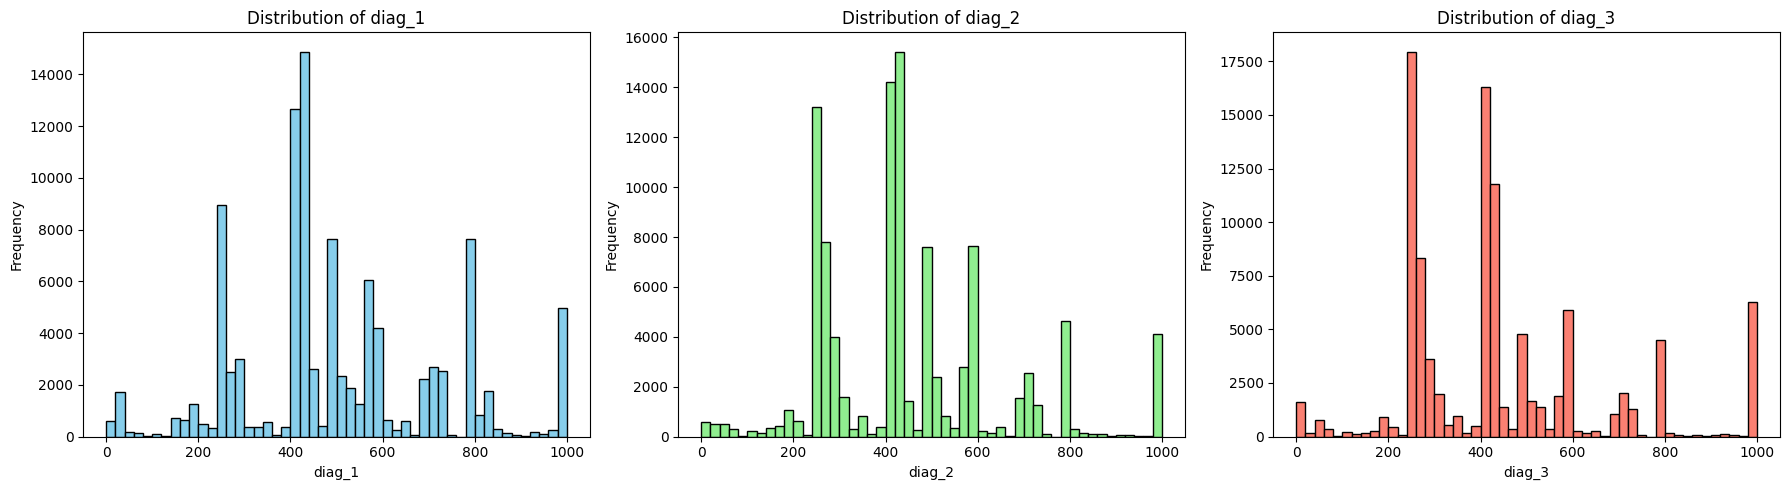

In [185]:
# Plot distribution of diag_1, diag_2, diag_3
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.hist(data['diag_1'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of diag_1')
plt.xlabel('diag_1')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(data['diag_2'], bins=50, color='lightgreen', edgecolor='black')
plt.title('Distribution of diag_2')
plt.xlabel('diag_2')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(data['diag_3'], bins=50, color='salmon', edgecolor='black')
plt.title('Distribution of diag_3')
plt.xlabel('diag_3')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

We convert age intervals to their midpoint values. 

In [186]:
def age_to_mid(age_str):
    # age_str is in the format "[20-30)"
    if isinstance(age_str, str) and '-' in age_str:
        nums = age_str.replace('[','').replace(')','').split('-')
        return (int(nums[0]) + int(nums[1])) // 2
    else:
        return None

data['age'] = data['age'].apply(age_to_mid)
data['age'].head()

0     5
1    15
2    25
3    35
4    45
Name: age, dtype: int64

We also reduce the number of categories for some categorical features by combining categories: 

The ">30 days" and "No readmission" categories are merged into a single "No readmission within 30 days" category


In [187]:
data['readmitted'] = data['readmitted'].apply(lambda x: 'YES' if x == '<30' else 'NO')
data['readmitted'].value_counts()

readmitted
NO     90409
YES    11357
Name: count, dtype: int64

The original dataset records the usage of 23 different medications. We introduce a new feature that counts the total number of drugs taken by each patient. 


In [188]:
drug_columns = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
] # exclude 'citoglipton' and 'examide' for they had been removed

# count the total number of medications used by each patient (as long as it's not "No", it's considered used)
data['num_drugs'] = data[drug_columns].apply(lambda row: sum(row != 'No'), axis=1)

In our earlier EDA, we found that admission_type_id and admission_source_id are strongly correlated: 

Cramér's V between admission_type_id and admission_source_id: 0.4096


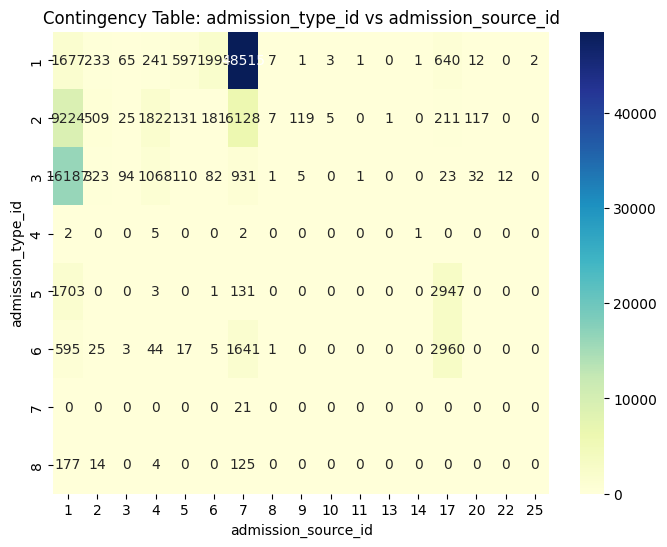

In [189]:
# Correlation analysis (Cramér's V) and visualization between admission type (admission_type_id) and admission source (admission_source_id)

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

def cramers_v(x, y):
    """Calculate Cramér's V to measure correlation between two categorical variables"""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.values.sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Bias correction
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

def plot_contingency_heatmap(df, col1, col2):
    """Plot contingency table heatmap for two categorical variables"""
    contingency = pd.crosstab(df[col1], df[col2])
    plt.figure(figsize=(8, 6))
    sns.heatmap(contingency, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f'Contingency Table: {col1} vs {col2}')
    plt.xlabel(col2)
    plt.ylabel(col1)
    plt.show()


v = cramers_v(data['admission_type_id'], data['admission_source_id'])
print(f"Cramér's V between admission_type_id and admission_source_id: {v:.4f}")
plot_contingency_heatmap(data, 'admission_type_id', 'admission_source_id')



Cramér's V = 0.6123 indeed indicates strong correlation between these two features, so we group the 4 most correlated combinations from the heatmap and group others as 'other' to avoid multicollinearity issues.
Therefore, we combine `admission_type_id` and `admission_source_id`:

Original:
- admission_type_id: 1=Emergency, 2=Urgent, 3=Elective, 4=other
- admission_source_id: 1=Physician referral, 7=Emergency room, 4=other

Create combined feature: admission_type_source

- Emergency_ER: admission_type == 1 and admission_source == 7
- Urgent_Physician: admission_type == 2 and admission_source == 1
- Elective_Physician: admission_type == 3 and admission_source == 1
- Urgent_ER: admission_type == 2 and admission_source == 7
- Other_Combination


In [190]:
# Create combined feature: admission_type_source
def create_admission_combination(row):
    admission_type = row['admission_type_id']
    admission_source = row['admission_source_id']
    
    # Combinations based on business logic
    if admission_type == 1 and admission_source == 7:  # Emergency + ER
        return 'Emergency_ER'
    elif admission_type == 2 and admission_source == 1:  # Urgent + Physician
        return 'Urgent_Physician'
    elif admission_type == 3 and admission_source == 1:  # Elective + Physician
        return 'Elective_Physician'
    elif admission_type == 2 and admission_source == 7:  # Urgent + ER
        return 'Urgent_ER'
    else:
        return 'Other_Combination'

# Apply combined feature
data['admission_type_source'] = data.apply(create_admission_combination, axis=1)

# Delete original two columns
data.drop(['admission_type_id', 'admission_source_id'], axis=1, inplace=True)

data.head()

,encounter_id,patient_nbr,race,gender,age,discharge_disposition_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,diag_1,diag_2,diag_3,num_drugs,admission_type_source
0,2278392,8222157,Caucasian,Female,5,25,1,41,0,1,...,No,No,No,No,NO,250,0,0,0,Other_Combination
1,149190,55629189,Caucasian,Female,15,1,3,59,0,18,...,No,No,Ch,Yes,NO,276,250,255,1,Emergency_ER
2,64410,86047875,AfricanAmerican,Female,25,1,2,11,5,13,...,No,No,No,Yes,NO,648,250,1000,1,Emergency_ER
3,500364,82442376,Caucasian,Male,35,1,2,44,1,16,...,No,No,Ch,Yes,NO,8,250,403,1,Emergency_ER
4,16680,42519267,Caucasian,Male,45,1,1,51,0,8,...,No,No,Ch,Yes,NO,197,157,250,2,Emergency_ER


In [191]:
#drop encounter_id	patient_nbr	 columns. Not relevant

data.drop(['encounter_id', 'patient_nbr'], axis=1, inplace=True)

In [192]:
data.describe().iloc[:,:12]

,age,discharge_disposition_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,diag_1,diag_2
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,65.967022,3.715642,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607,501.629130,451.103060
std,15.940838,5.280166,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600,214.898338,198.686789
min,5.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,55.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,410.000000,276.000000
50%,65.000000,1.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,441.000000,427.000000
75%,75.000000,4.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,599.000000,569.000000
max,95.000000,28.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,1000.000000,1000.000000


In [193]:
data.describe().iloc[:,12:]

,diag_3,num_drugs
count,101766.000000,101766.000000
mean,441.231168,1.179706
std,219.514279,0.920190
min,0.000000,0.000000
25%,274.000000,1.000000
50%,411.000000,1.000000
75%,535.000000,2.000000
max,1000.000000,6.000000


In [194]:
#Get number of unique values for each discrete variable in the dataset.
for col in data.describe().columns:
    if data[col].dtype == int:
        print(f'{col}:', data[col].nunique())

In [195]:
#Get value counts for SpecialDay
data.readmitted.value_counts()

readmitted
NO     90409
YES    11357
Name: count, dtype: int64

In [196]:
#Get non-numerical features.
non_num_cols = list(set(data.columns) - set(data.describe().columns))
print('Non-numerical features: ',non_num_cols)

Non-numerical features:  ['rosiglitazone', 'repaglinide', 'admission_type_source', 'acarbose', 'readmitted', 'troglitazone', 'change', 'glipizide-metformin', 'race', 'miglitol', 'glyburide-metformin', 'tolazamide', 'glipizide', 'glyburide', 'chlorpropamide', 'glimepiride', 'nateglinide', 'insulin', 'metformin-rosiglitazone', 'diabetesMed', 'glimepiride-pioglitazone', 'gender', 'acetohexamide', 'tolbutamide', 'metformin', 'metformin-pioglitazone', 'pioglitazone']


In [197]:
#Get numerical features.
num_cols = list(set(data.describe().columns))
print('Numerical features: ', num_cols)

Numerical features:  ['time_in_hospital', 'age', 'number_inpatient', 'discharge_disposition_id', 'num_procedures', 'number_emergency', 'diag_2', 'num_medications', 'number_diagnoses', 'diag_1', 'diag_3', 'number_outpatient', 'num_drugs', 'num_lab_procedures']


We peform one-hot encoding on categorical features.

In [198]:
#Create list with categorical features' names.
#data.readmitted[data.readmitted =='>30'] = 2
data.readmitted[data.readmitted =='YES'] = 1
data.readmitted[data.readmitted =='NO'] = 0

target = data.readmitted.copy()
non_num_cols.remove('readmitted')
data = data.drop(columns= ['readmitted'])
nonum_feats_names = non_num_cols

#Create list with numerical features' names.
num_cols_names = num_cols

In [199]:
#Assign appropriate data type to categorical variables.
nonum_feats = data[nonum_feats_names].astype('category')
nonum_feats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   rosiglitazone             101766 non-null  category
 1   repaglinide               101766 non-null  category
 2   admission_type_source     101766 non-null  category
 3   acarbose                  101766 non-null  category
 4   troglitazone              101766 non-null  category
 5   change                    101766 non-null  category
 6   glipizide-metformin       101766 non-null  category
 7   race                      101766 non-null  category
 8   miglitol                  101766 non-null  category
 9   glyburide-metformin       101766 non-null  category
 10  tolazamide                101766 non-null  category
 11  glipizide                 101766 non-null  category
 12  glyburide                 101766 non-null  category
 13  chlorpropamide            101

In [200]:
#One-hot-code categorical variables and dropping the reference value.
ohc_feats = pd.get_dummies(nonum_feats,drop_first=True)
ohc_feats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 60 columns):
 #   Column                                   Non-Null Count   Dtype
---  ------                                   --------------   -----
 0   rosiglitazone_No                         101766 non-null  bool 
 1   rosiglitazone_Steady                     101766 non-null  bool 
 2   rosiglitazone_Up                         101766 non-null  bool 
 3   repaglinide_No                           101766 non-null  bool 
 4   repaglinide_Steady                       101766 non-null  bool 
 5   repaglinide_Up                           101766 non-null  bool 
 6   admission_type_source_Emergency_ER       101766 non-null  bool 
 7   admission_type_source_Other_Combination  101766 non-null  bool 
 8   admission_type_source_Urgent_ER          101766 non-null  bool 
 9   admission_type_source_Urgent_Physician   101766 non-null  bool 
 10  acarbose_No                              101766 non-null

# 3. Model evaluation 

We first begin with plain vanilla classification models before further investigating a series of further enhacements. 



## 3.1 Plain Vanilla Classification Models

We start off by evaluating the basic versions of the following classification models: 
* Logistic Regression
* Random Forest
* Gradient Boosting

In [201]:
ohc_data = pd.concat([data[num_cols_names], ohc_feats],axis=1)
ohc_data = ohc_data.apply(pd.to_numeric)
target = target.apply(pd.to_numeric)
#results1 = baseline_models(data=[ohc_data,target], verbose=True)


In [202]:
import os 

from sklearn.utils.validation import column_or_1d
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.utils.validation import column_or_1d
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, roc_curve

X_train, X_test, y_train, y_test = train_test_split(ohc_data, target, test_size = 0.25, random_state = 42)
X_test0 = X_test.copy() 

y_train = column_or_1d(y_train, warn=True)
y_train = y_train.ravel()
vanilla_metrics = {}

def output_metrics(model, X_test, y_test, model_label):

    predictions = model.predict(X_test)
    y_scores = model.predict_proba(X_test)[:, 1]

    # Compute Precision and Recall for different thresholds.
    precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
    # Calculate Area Under the PR curve.
    pr_auc = auc(recall, precision)
    # Print the PR AUC
    print(f'PR AUC: {pr_auc}')

    roc_auc = roc_auc_score(y_test, y_scores)
    print(f'model ROC AUC score: {roc_auc}')
    accuracy = accuracy_score(y_test, predictions)
    print(f"Accuracy: {accuracy:.2f}")
    print("\nClassification Report:\n",classification_report(y_test, predictions))

    conf_matrix = confusion_matrix(y_test, predictions)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot the Precision-Recall curve.
    plt.plot(recall, precision, marker='.', label= model_label)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall curve')
    plt.legend()
    plt.show()


    return {"classification_report":classification_report(y_test, predictions, output_dict=True), "roc_auc": roc_auc, "pr_auc": pr_auc}

PR AUC: 0.19284208084970525
model ROC AUC score: 0.6442307950739767
Accuracy: 0.67

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.69      0.78     22593
           1       0.17      0.51      0.25      2849

    accuracy                           0.67     25442
   macro avg       0.54      0.60      0.52     25442
weighted avg       0.83      0.67      0.72     25442

Confusion Matrix:
 [[15478  7115]
 [ 1408  1441]]


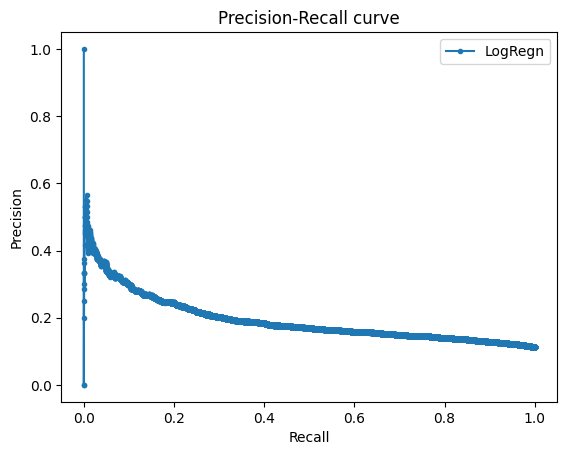

In [203]:

# during the course of developing and debugging this notebook, there are a number of occasions where we need to rerun the entire notebook. 
# To save time by avoiding running long calculations many times, we save and reload the trained models occasionally when these models 
# take a long time to run. 

model_label = 'LogRegn'
if not os.path.exists('log_model.pkl'):
    logmodel = LogisticRegression(multi_class='multinomial', solver='lbfgs',class_weight = 'balanced', max_iter=20000)
    logmodel.fit(X_train, y_train)
    with open('log_model.pkl','wb') as f:
        pickle.dump(logmodel,f)
else:
    with open('log_model.pkl', 'rb') as f:
        logmodel = pickle.load(f) # apparently pickling sometimes jumbles up the order of features inside pickled models.  
        lmd = logmodel.__dict__
        feature_columns = list(lmd['feature_names_in_'])
        # to avoid errors, we need to rearrange the sequence of features in test data to match that of the pickled model
        X_test = X_test[feature_columns]

vanilla_metrics[model_label] = output_metrics(logmodel, X_test, y_test, model_label)
X_test = X_test0

PR AUC: 0.1945448910845288
model ROC AUC score: 0.6372457824456232
Accuracy: 0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     22593
           1       0.50      0.00      0.01      2849

    accuracy                           0.89     25442
   macro avg       0.69      0.50      0.47     25442
weighted avg       0.84      0.89      0.84     25442

Confusion Matrix:
 [[22584     9]
 [ 2840     9]]


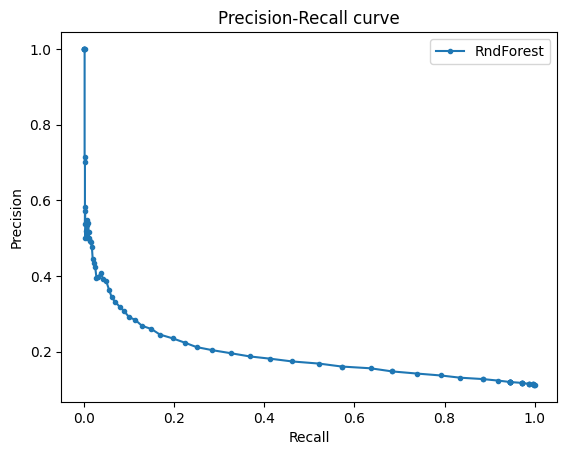

In [204]:
#ordinal_encoder = ce.OrdinalEncoder()
X_train_forest = X_train.copy()
X_test_forest = X_test.copy()
y_train_forest = y_train.copy()
y_test_forest = y_test.copy()

model_label = "RndForest"
# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_forest, y_train_forest)

vanilla_metrics[model_label] = output_metrics(rf, X_test, y_test, model_label)

PR AUC: 0.2262719821465221
model ROC AUC score: 0.6798459507263119
Accuracy: 0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     22593
           1       0.57      0.01      0.02      2849

    accuracy                           0.89     25442
   macro avg       0.73      0.51      0.48     25442
weighted avg       0.85      0.89      0.84     25442

Confusion Matrix:
 [[22568    25]
 [ 2816    33]]


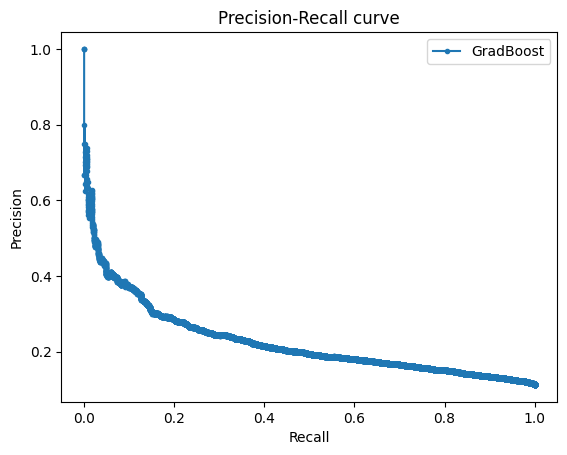

In [205]:
X_train_gradient = X_train.copy()
X_test_gradient = X_test.copy()
y_train_gradient = y_train.copy()
y_test_gradient = y_test.copy()
# Train Random Forest
model_label = "GradBoost"
rf = GradientBoostingClassifier()
rf.fit(X_train_gradient, y_train_gradient)

vanilla_metrics[model_label] = output_metrics(rf, X_test, y_test, model_label)

We summarize the results for the various vanilla models compared:

In [206]:
dd = []
for k,v in vanilla_metrics.items():
    dd.append({'model_label': k, 'pr_auc': v['pr_auc'], 'roc_auc':v['roc_auc']})

vanilla_summary = pd.DataFrame(dd).set_index('model_label')
print(vanilla_summary)


               pr_auc   roc_auc
model_label                    
LogRegn      0.192842  0.644231
RndForest    0.194545  0.637246
GradBoost    0.226272  0.679846


The Gradient Boosting Classifier is the best performing so far. We next investigate whether the results can be improved by applying scaling. 

## 3.2 Applying standard scaler and stratified training and test sets

In the next section, we investigate the effect of applying the standard scaler and stratified training and test sets.

In [207]:
#Create a final dataframe with all numerical variables in the first columns.
final_df = pd.concat([ohc_data[num_cols_names],ohc_feats],axis=1)
final_df  = final_df.apply(pd.to_numeric)
#Create final train and test sets startified according to the target variable. 
X_train, X_test, y_train, y_test = train_test_split(final_df,target, test_size = 0.30,stratify=target, 
                                                    random_state=123)

X_test0 = X_test

'''Scaling the data first fitting it and transforming the training set
to later aply the fit to transform the test set.'''
#Instantiate Satandard Scaler
scaler = StandardScaler()
#Fit transform the numerical features in the training dataset to a new dataframe
scaled_numfeats_train = pd.DataFrame(scaler.fit_transform(X_train[num_cols_names]), 
                                     columns=num_cols_names, index= X_train.index)
#Integrate scaled values to the training set
for col in num_cols_names:
    X_train[col] = scaled_numfeats_train[col]
#Transform the numerical features inthe training dataset to a new dataframe
scaled_numfeats_test = pd.DataFrame(scaler.transform(X_test[num_cols_names]),
                                    columns=num_cols_names, index= X_test.index)
#Integrate scaled values to the test set
for col in num_cols_names:
    X_test[col] = scaled_numfeats_test[col]

y_train = column_or_1d(y_train, warn=True)
y_train = y_train.ravel()

scaled_metrics = {}

PR AUC: 0.19962928572317717
model ROC AUC score: 0.641989815152598
Accuracy: 0.66

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.68      0.78     27123
           1       0.17      0.51      0.25      3407

    accuracy                           0.66     30530
   macro avg       0.54      0.60      0.52     30530
weighted avg       0.83      0.66      0.72     30530

Confusion Matrix:
 [[18488  8635]
 [ 1658  1749]]


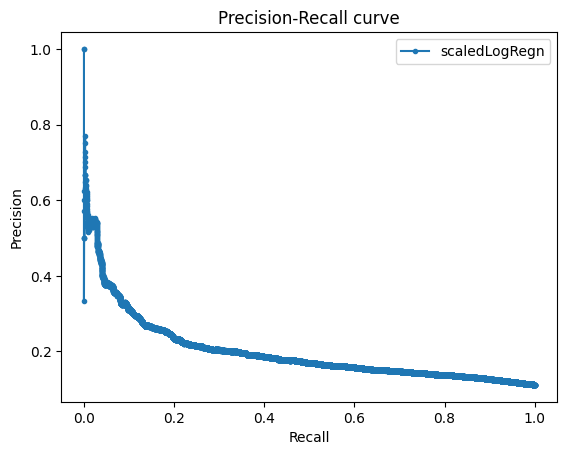

In [208]:

model_label = 'scaledLogRegn'

# log model takes a while to run, so here we pickle it 
if not os.path.exists("Slogmodel.pkl"):
    logmodel = LogisticRegression(multi_class='multinomial', solver='lbfgs',class_weight = 'balanced', max_iter=20000)
    logmodel.fit(X_train, y_train)
    with open("Slogmodel.pkl","wb") as f:
        pickle.dump(logmodel,f)
else:
    with open("Slogmodel.pkl", "rb") as f:
        logmodel = pickle.load(f) # apparently pickling sometimes jumble up the order of features inside pickled models 
        lmd = logmodel.__dict__
        feature_columns = list(lmd['feature_names_in_'])
        X_test = X_test[feature_columns]

scaled_metrics[model_label] = output_metrics(logmodel, X_test, y_test, model_label)
X_test = X_test0 


PR AUC: 0.20217041312314676
model ROC AUC score: 0.6346976428820426
Accuracy: 0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     27123
           1       0.73      0.01      0.02      3407

    accuracy                           0.89     30530
   macro avg       0.81      0.50      0.48     30530
weighted avg       0.87      0.89      0.84     30530

Confusion Matrix:
 [[27113    10]
 [ 3380    27]]


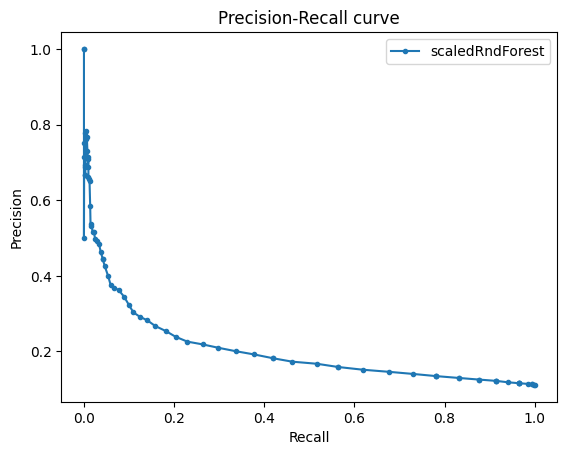

In [209]:
model_label = 'scaledRndForest'

X_train_forest = X_train.copy()
X_test_forest = X_test.copy()
y_train_forest = y_train.copy()
y_test_forest = y_test.copy()
# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_forest, y_train_forest)

scaled_metrics[model_label] = output_metrics(rf, X_test, y_test, model_label)

PR AUC: 0.22807173578277365
model ROC AUC score: 0.6756179636752686
Accuracy: 0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     27123
           1       0.63      0.01      0.02      3407

    accuracy                           0.89     30530
   macro avg       0.76      0.50      0.48     30530
weighted avg       0.86      0.89      0.84     30530

Confusion Matrix:
 [[27107    16]
 [ 3380    27]]


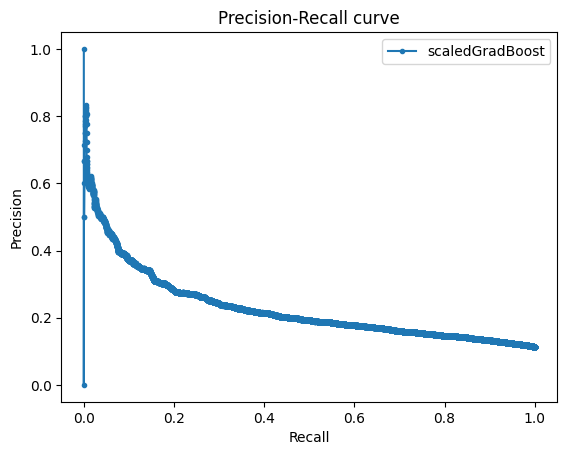

In [210]:
model_label = 'scaledGradBoost'
X_train_gradient = X_train.copy()
X_test_gradient = X_test.copy()
y_train_gradient = y_train.copy()
y_test_gradient = y_test.copy()
# Train Random Forest
rf = GradientBoostingClassifier()
rf.fit(X_train_gradient, y_train_gradient)

scaled_metrics[model_label] = output_metrics(rf, X_test, y_test, model_label)

We compare the PR-AUC and ROC-AUC scores of the models before and after the scaling transformation. 

In [211]:
dd = []
for k,v in vanilla_metrics.items():
    scaled = scaled_metrics['scaled' + k]
    dd.append({'model_label': k, 'pr_auc': v['pr_auc'], 'scaled_pr_auc': scaled['pr_auc'], 'roc_auc':v['roc_auc'], 'scaled_roc_auc': scaled['roc_auc'] })

scaled_summary = pd.DataFrame(dd).set_index('model_label')
print(scaled_summary)



               pr_auc  scaled_pr_auc   roc_auc  scaled_roc_auc
model_label                                                   
LogRegn      0.192842       0.199629  0.644231        0.641990
RndForest    0.194545       0.202170  0.637246        0.634698
GradBoost    0.226272       0.228072  0.679846        0.675618


Unforunately, applying the scaling transformation does not seem to have a significant effect in improving the metrics. We investigate whether the metrics can be improved by accounting for the imbalanced dataset by applying the Synthetic Minority Over-sampling Technique to create synthetic data that helps balance the target incidence. 

## 3.3 SMOTE


In [212]:
total_cols = len(num_cols_names) + len(non_num_cols)
print(total_cols)

# takes a long time to run, so we pickle this as well 
if not os.path.exists("sm.pkl"):
    cat_col_index = list(range(len(num_cols_names),total_cols))
    sm = SMOTENC(categorical_features=cat_col_index, random_state=123, sampling_strategy={0: 90409, 1: 90409})
    X_trainres, y_trainres = sm.fit_resample(X_train, y_train)
    pickle_dict = {"X_trainres":X_trainres, "y_trainres":y_trainres}
    with open("sm.pkl","wb") as f:
        pickle.dump(pickle_dict, f)
else:
    with open("sm.pkl","rb") as f:
        pickle_dict = pickle.load(f)
    for k,v in pickle_dict.items():
        globals()[k] = v

    X_trainres = X_trainres[ list(X_train.columns)] # apparently sometimes the ordering of stuff gets jumbled up after pickling and unpickling 


y_trainres = column_or_1d(y_trainres, warn=True)
y_trainres = y_trainres.ravel()


smote_metrics = {}

40


PR AUC: 0.1694145867192032
model ROC AUC score: 0.5843468461046921
Accuracy: 0.76

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.82      0.86     27123
           1       0.17      0.29      0.21      3407

    accuracy                           0.76     30530
   macro avg       0.54      0.56      0.54     30530
weighted avg       0.82      0.76      0.79     30530

Confusion Matrix:
 [[22366  4757]
 [ 2430   977]]


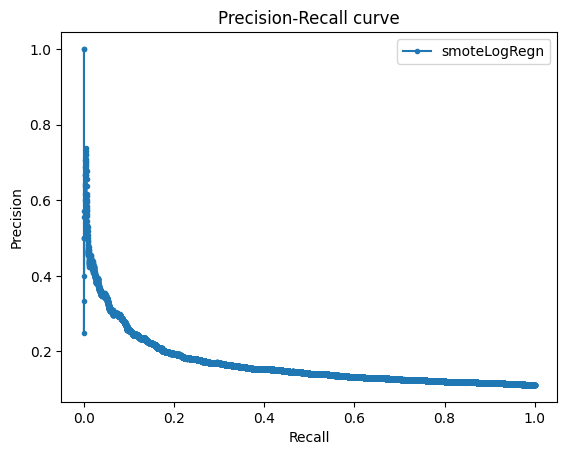

In [213]:
model_label = 'smoteLogRegn'
logmodel = LogisticRegression(multi_class='multinomial', solver='lbfgs',class_weight = 'balanced', max_iter=20000)
logmodel.fit(X_trainres, y_trainres)

smote_metrics[model_label] = output_metrics(logmodel, X_test, y_test, model_label)


PR AUC: 0.18500076961642037
model ROC AUC score: 0.6356501247223443
Accuracy: 0.88

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94     27123
           1       0.33      0.03      0.06      3407

    accuracy                           0.88     30530
   macro avg       0.61      0.51      0.50     30530
weighted avg       0.83      0.88      0.84     30530

Confusion Matrix:
 [[26894   229]
 [ 3294   113]]


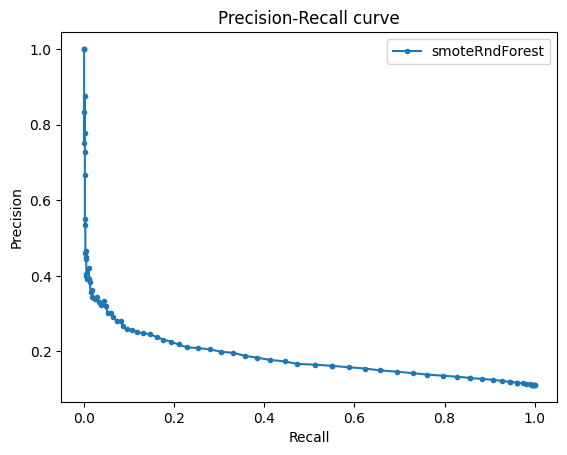

In [214]:
model_label = 'smoteRndForest'
X_train_forest = X_trainres.copy()
X_test_forest = X_test.copy()
y_train_forest = y_trainres.copy()
y_test_forest = y_test.copy()
# Train Random Forest
rf = RandomForestClassifier(random_state=42)

if not os.path.exists("SMOTE_rf.pkl"):
    rf.fit(X_train_forest, y_train_forest)
    with open("SMOTE_rf.pkl","wb") as f:
        pickle.dump(rf, f)
else:
    with open("SMOTE_rf.pkl","rb") as f:
        rf = pickle.load(f)
        rfd = rf.__dict__
        X_test_forest = X_test_forest[list(rfd['feature_names_in_'])]

smote_metrics[model_label] = output_metrics(rf, X_test_forest, y_test_forest, model_label)

PR AUC: 0.19358548781831553
model ROC AUC score: 0.6416655739589645
Accuracy: 0.87

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93     27123
           1       0.27      0.11      0.16      3407

    accuracy                           0.87     30530
   macro avg       0.58      0.54      0.54     30530
weighted avg       0.83      0.87      0.84     30530

Confusion Matrix:
 [[26112  1011]
 [ 3030   377]]


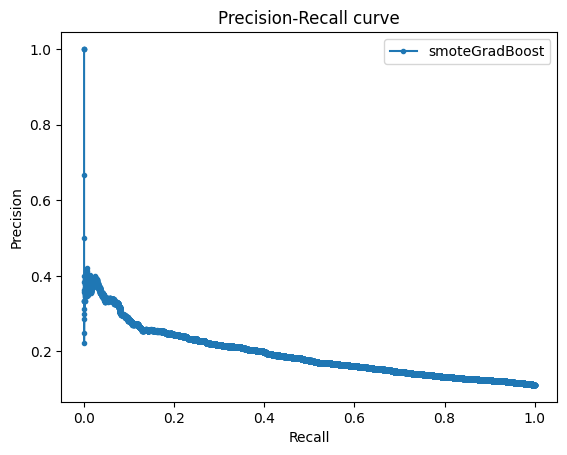

In [215]:
model_label = 'smoteGradBoost'
X_train_gradient = X_trainres.copy()
X_test_gradient = X_test.copy()
y_train_gradient = y_trainres.copy()
y_test_gradient = y_test.copy()
# Train Gradient
rf = GradientBoostingClassifier()

if not os.path.exists("SMOTE_gradient.pkl"):
    rf.fit(X_train_gradient, y_train_gradient)
    with open("SMOTE_gradient.pkl","wb") as f:
        pickle.dump(rf, f)
else:
    with open("SMOTE_gradient.pkl","rb") as f:
        rf = pickle.load(f)
        rfd = rf.__dict__
        X_test_gradient = X_test_gradient[list(rfd['feature_names_in_'])]

smote_metrics[model_label] = output_metrics(rf, X_test_gradient, y_test_gradient, model_label)

In [216]:
dd = []
for k,v in vanilla_metrics.items():
    smoted = smote_metrics['smote' + k]
    dd.append({'model_label': k, 'pr_auc': v['pr_auc'], 'smote_pr_auc': smoted['pr_auc'], 'roc_auc':v['roc_auc'], 'smote_roc_auc': smoted['roc_auc'] })

smote_summary = pd.DataFrame(dd).set_index('model_label')
print(smote_summary)


               pr_auc  smote_pr_auc   roc_auc  smote_roc_auc
model_label                                                 
LogRegn      0.192842      0.169415  0.644231       0.584347
RndForest    0.194545      0.185001  0.637246       0.635650
GradBoost    0.226272      0.193585  0.679846       0.641666


Applying SMOTE has a detrimental effect on the metrics. We therefore turn our attention to hyperparameter tuning instead. 
Before jumping into tunning the models, we will look into principal component analysis (PCA) to reduce the linear dimensionality of the data and increase model information processing speed. We plot the the PCA spectrum to find the optimal range of n_estimators that captures the most variance in the data. 

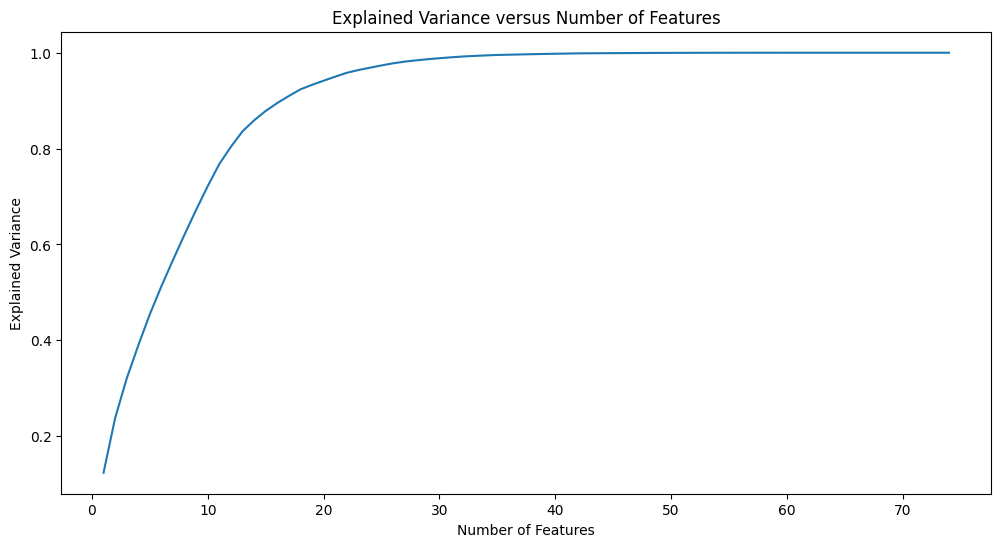

In [217]:
#Instantiate Principal Component Analysis.
pca=PCA()
X_pca = pca.fit_transform(X_trainres)
fig = plt.figure(figsize=(12,6))
plt.plot(range(1,X_trainres.shape[1]+1), pca.explained_variance_ratio_.cumsum())
plt.title('Explained Variance versus Number of Features')
plt.ylabel('Explained Variance')
plt.xlabel('Number of Features')
plt.show()

From the graph above we noticed that the rate of increase in the total explained variance starts to diminish rate at around n_components=15. This number of components also reduces dimensionality by a quarter while explaining above 90% of the total variance. We try pipelines  with n_components of 15,20, and 25.

In [218]:
for n in [10,15,20,25]:
    pca_n = PCA(n_components=n)
    X_pcan = pca_n.fit_transform(X_trainres)
    tev = round(np.sum(pca_n.explained_variance_ratio_)*100,2)
    print('Number of Fetaures: ',n, 'Total Explained Variance: ',tev,'%')

Number of Fetaures:  10 Total Explained Variance:  72.19 %
Number of Fetaures:  15 Total Explained Variance:  87.85 %
Number of Fetaures:  20 Total Explained Variance:  94.16 %
Number of Fetaures:  25 Total Explained Variance:  97.35 %


## 3.4 Hyperparameter Tuning


We next proceed to perform hyperparameter tuning on logistic regression, random forest, gradient boosting, and decision tree classifiers. 

In [219]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X = ohc_data.copy()
y = target.astype(int).ravel()

pipelines = {
    "LR": Pipeline([
        ("scale", StandardScaler(with_mean=False)),   
        ("clf", LogisticRegression(max_iter=5000, solver="liblinear", class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "RF": Pipeline([
        ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "GB": Pipeline([
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ]),
    "DT": Pipeline([
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"))
])
}

param_grids = {
    "LR": {
        "clf__C": [0.1, 0.5, 1.0, 2.0]
    },
    "RF": {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [None, 12, 20],
        "clf__min_samples_leaf": [1, 2]
    },
    "GB": {
        "clf__n_estimators": [150, 250],
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [2, 3]
    },
    "DT": {
        "clf__max_depth": [3, 5, 10, None],
        "clf__min_samples_split": [2, 10, 50],
        "clf__min_samples_leaf": [1, 5, 10],
        "clf__ccp_alpha": [0.0, 1e-3, 1e-2]
    }
}

rows = []
best_models = {}
if not os.path.exists("SmodHyper.pkl"):
    for name, pipe in pipelines.items():
        grid = GridSearchCV(
            pipe, param_grids[name],
            scoring="roc_auc",
            cv=cv,
            n_jobs=-1,
            refit=True,
            verbose=1
        )
        grid.fit(X, y)
        rows.append({
            "model": name,
            "best_roc_auc": grid.best_score_,
            "best_params": grid.best_params_,
        })
        best_models[name] = grid.best_estimator_
    with open("SmodHyper.pkl","wb") as f:
        pickle.dump(rows,f)
else:
    with open("SmodHyper.pkl", "rb") as f:
        rows = pickle.load(f)

pd.DataFrame(rows).sort_values("best_roc_auc", ascending=False)


,model,best_roc_auc,best_params
2,GB,0.675727,"{'clf__learning_rate': 0.1, 'clf__max_depth': ..."
1,RF,0.661059,"{'clf__max_depth': 12, 'clf__min_samples_leaf'..."
3,DT,0.650650,"{'clf__ccp_alpha': 0.0, 'clf__max_depth': 5, '..."
0,LR,0.640205,{'clf__C': 2.0}


From the above, it evident that the GB family of models wins. We perform a gridsearch to tune the hyperparameters for various members of the GB family, namely GB, XGB, and LightGBM, and combine this with stratifiedKFold (5 fold) for cross validation.

In [220]:
from collections import Counter
from joblib import parallel_backend #to speed up the algorithms

RANDOM_STATE = 42

# ----- CV splitter -----
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ----- class balance numbers & weights -----
cnt = Counter(y_train)
pos = cnt[1]; neg = cnt[0]
pos_weight = neg / max(pos, 1)                # for XGB/LGBM scale_pos_weight arm
sw_balanced = compute_sample_weight('balanced', y_train)  # for GB weighted via sample_weight

results = []
# this takes about two hours to run. We pickle the results. 
if not os.path.exists("GBhyper.pkl"):
    # ========= 1) Gradient Boosting (sklearn) =========
    gb_grid = {
        "clf__n_estimators": [200, 400],
        "clf__learning_rate": [0.10, 0.05],
        "clf__max_depth": [3, 5],
    }

    # (A) baseline (no resampling/weights)
    gb_base = ImbPipeline([("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))])
    print("GB | baseline (no resampling)")
    gs_gb_base = GridSearchCV(gb_base, gb_grid, cv=cv5, scoring="roc_auc",
                            n_jobs=-1, verbose=1)
    with parallel_backend('threading'):
        gs_gb_base.fit(X_train, y_train)
    results.append(dict(model="GB", strategy="baseline",
                        best_roc_auc=gs_gb_base.best_score_,
                        best_params=gs_gb_base.best_params_))

    # (B) weighted via sample_weight at fit()
    gb_w = ImbPipeline([("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))])
    print("GB | weighted (sample_weight)")
    gs_gb_w = GridSearchCV(gb_w, gb_grid, cv=cv5, scoring="roc_auc",
                        n_jobs=-1, verbose=1)
    # pass weights through the pipeline step name
    with parallel_backend('threading'):
        gs_gb_w.fit(X_train, y_train, **{"clf__sample_weight": sw_balanced})
    results.append(dict(model="GB", strategy="weighted(sample_weight)",
                        best_roc_auc=gs_gb_w.best_score_,
                        best_params=gs_gb_w.best_params_))

    # (C) SMOTE arm (resample only inside train folds)
    gb_smote = ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ])
    print("GB | SMOTE")
    gs_gb_smote = GridSearchCV(gb_smote, gb_grid, cv=cv5, scoring="roc_auc",
                            n_jobs=-1, verbose=1)  
    with parallel_backend('threading'):    
        gs_gb_smote.fit(X_train, y_train)
    results.append(dict(model="GB", strategy="SMOTE",
                        best_roc_auc=gs_gb_smote.best_score_,
                        best_params=gs_gb_smote.best_params_))


    # ========= 2) XGBoost =========
    xgb_common = dict(
        objective="binary:logistic", eval_metric="logloss",
        tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE
    )

    # (A) weighted (scale_pos_weight search)
    xgb_base = ImbPipeline([("clf", XGBClassifier(**xgb_common))])
    xgb_grid_weight = {
        "clf__n_estimators": [300, 600],
        "clf__learning_rate": [0.10, 0.05],
        "clf__max_depth": [4, 6],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0],
        "clf__reg_lambda": [0.0, 1.0],
        "clf__scale_pos_weight": [pos_weight*0.75, pos_weight, pos_weight*1.25],
    }
    print("XGB | weighted (scale_pos_weight)")
    gs_xgb_w = GridSearchCV(xgb_base, xgb_grid_weight, cv=cv5, scoring="roc_auc",
                            n_jobs=-1, verbose=1, error_score='raise')
    with parallel_backend('threading'):
        gs_xgb_w.fit(X_train, y_train)
    results.append(dict(model="XGB", strategy="weighted",
                        best_roc_auc=gs_xgb_w.best_score_,
                        best_params=gs_xgb_w.best_params_))

    # (B) SMOTE arm
    xgb_smote = ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
        ("clf", XGBClassifier(**xgb_common)),
    ])
    xgb_grid_smote = {
        "clf__n_estimators": [300, 600],
        "clf__learning_rate": [0.10, 0.05],
        "clf__max_depth": [4, 6],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0],
        "clf__reg_lambda": [0.0, 1.0],
    }
    print("XGB | SMOTE")
    gs_xgb_smote = GridSearchCV(xgb_smote, xgb_grid_smote, cv=cv5, scoring="roc_auc",
                                n_jobs=-1, verbose=1, error_score='raise')  
    with parallel_backend('threading'):    
        gs_xgb_smote.fit(X_train, y_train)
    results.append(dict(model="XGB", strategy="SMOTE",
                        best_roc_auc=gs_xgb_smote.best_score_,
                        best_params=gs_xgb_smote.best_params_))


    # ========= 3) LightGBM =========
    lgb_common = dict(random_state=RANDOM_STATE, n_jobs=1)

    # (A) weighted
    lgb_base = ImbPipeline([("clf", LGBMClassifier(**lgb_common))])
    lgb_grid_weight = {
        "clf__n_estimators": [400, 800],
        "clf__learning_rate": [0.10, 0.05],
        "clf__num_leaves": [31, 63],
        "clf__max_depth": [-1, 8],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0],
        "clf__reg_lambda": [0.0, 1.0],
        "clf__scale_pos_weight": [pos_weight*0.75, pos_weight, pos_weight*1.25],
    }
    print("LGBM | weighted (scale_pos_weight)")
    gs_lgb_w = GridSearchCV(lgb_base, lgb_grid_weight, cv=cv5, scoring="roc_auc",
                            n_jobs=-1, verbose=1)
    with parallel_backend('threading'):
        gs_lgb_w.fit(X_train, y_train)
    results.append(dict(model="LGBM", strategy="weighted",
                        best_roc_auc=gs_lgb_w.best_score_,
                        best_params=gs_lgb_w.best_params_))

    # (B) SMOTE arm
    lgb_smote = ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
        ("clf", LGBMClassifier(**lgb_common)),
    ])
    lgb_grid_smote = {
        "clf__n_estimators": [400, 800],
        "clf__learning_rate": [0.10, 0.05],
        "clf__num_leaves": [31, 63],
        "clf__max_depth": [-1, 8],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0],
        "clf__reg_lambda": [0.0, 1.0],
    }
    print("LGBM | SMOTE")
    gs_lgb_smote = GridSearchCV(lgb_smote, lgb_grid_smote, cv=cv5, scoring="roc_auc",
                                n_jobs=-1, verbose=1)  
    with parallel_backend('threading'):     
        gs_lgb_smote.fit(X_train, y_train)
    results.append(dict(model="LGBM", strategy="SMOTE",
                        best_roc_auc=gs_lgb_smote.best_score_,
                        best_params=gs_lgb_smote.best_params_))

    keys = ['gs_xgb_w', 'gs_gb_base', 'gs_gb_w', 'gs_lgb_w', 'gs_lgb_smote', 'gs_xgb_smote', 'gs_gb_smote','results']
    pickle_dict = {k: globals()[k] for k in keys}
    with open('GBhyper.pkl','wb') as f:
        pickle.dump(pickle_dict, f)
else:
    with open('GBhyper.pkl', 'rb') as f:
        dd = pickle.load(f)
        for k,v in dd.items():
            globals()[k] = v

# --- summary table (CV on TRAIN) ---
df_cv = pd.DataFrame(results).sort_values("best_roc_auc", ascending=False).reset_index(drop=True)
display(df_cv)


,model,strategy,best_roc_auc,best_params
0,XGB,weighted,0.672604,"{'clf__colsample_bytree': 0.8, 'clf__learning_..."
1,GB,baseline,0.672599,"{'clf__learning_rate': 0.05, 'clf__max_depth':..."
2,GB,weighted(sample_weight),0.669521,"{'clf__learning_rate': 0.1, 'clf__max_depth': ..."
3,LGBM,weighted,0.666341,"{'clf__colsample_bytree': 0.8, 'clf__learning_..."
4,LGBM,SMOTE,0.663558,"{'clf__colsample_bytree': 0.8, 'clf__learning_..."
5,GB,SMOTE,0.652600,"{'clf__learning_rate': 0.05, 'clf__max_depth':..."
6,XGB,SMOTE,0.651693,"{'clf__colsample_bytree': 0.8, 'clf__learning_..."


Based on ROC_AUC, XGB weighted is the winner, althought it is very close. Let's obtain its metrics and confusion matrix.

In [221]:


# --- 1) Pull the best XGB pipeline from your grid search and (re)fit on full training data
best_params = gs_xgb_w.best_params_
print("Best XGB (weighted) params from CV:\n", best_params)

best_xgb_pipe = gs_xgb_w.best_estimator_   # already refit=True by default, but we refit explicitly to be safe
best_xgb_pipe.fit(X_train, y_train)

# --- 2) Predict probabilities on the held-out test set
proba = best_xgb_pipe.predict_proba(X_test)[:, 1]

# Threshold-free metrics
roc = roc_auc_score(y_test, proba)
pr  = average_precision_score(y_test, proba)  # PR-AUC (a.k.a. Average Precision)

# --- 3) Metrics at threshold=0.50
pred_05 = (proba >= 0.50).astype(int)
acc_05  = accuracy_score(y_test, pred_05)
f1_05   = f1_score(y_test, pred_05)
prec_05 = precision_score(y_test, pred_05, zero_division=0)
rec_05  = recall_score(y_test, pred_05)
cm_05   = confusion_matrix(y_test, pred_05)  # [[TN, FP],[FN, TP]]

# --- 4) Find the single threshold that maximizes F1 on the test set
p, r, thr = precision_recall_curve(y_test, proba)        # thr has length len(p)-1
f1_curve = 2 * (p * r) / (p + r + 1e-12)
i_best = int(np.nanargmax(f1_curve[:-1]))                # ignore the last point (no threshold)
t_best = float(thr[i_best])

pred_b = (proba >= t_best).astype(int)
acc_b  = accuracy_score(y_test, pred_b)
f1_b   = f1_score(y_test, pred_b)
prec_b = precision_score(y_test, pred_b, zero_division=0)
rec_b  = recall_score(y_test, pred_b)
cm_b   = confusion_matrix(y_test, pred_b)

# --- 5) Print a compact report
print(f"\nXGB (weighted) — Test ROC-AUC: {roc:.3f} | PR-AUC: {pr:.3f}")
print(f"Best-F1 threshold ≈ {t_best:.3f}")

print("\nMetrics @ threshold 0.50")
print(f"  Accuracy : {acc_05:.3f}")
print(f"  Precision: {prec_05:.3f}")
print(f"  Recall   : {rec_05:.3f}")
print(f"  F1       : {f1_05:.3f}")
print("  Confusion matrix [ [TN, FP], [FN, TP] ]:\n", cm_05)

print("\nMetrics @ best-F1")
print(f"  Accuracy : {acc_b:.3f}")
print(f"  Precision: {prec_b:.3f}")
print(f"  Recall   : {rec_b:.3f}")
print(f"  F1       : {f1_b:.3f}")
print("  Confusion matrix [ [TN, FP], [FN, TP] ]:\n", cm_b)


Best XGB (weighted) params from CV:
 {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 300, 'clf__reg_lambda': 1.0, 'clf__scale_pos_weight': 5.970377358490566, 'clf__subsample': 0.8}

XGB (weighted) — Test ROC-AUC: 0.681 | PR-AUC: 0.233
Best-F1 threshold ≈ 0.480

Metrics @ threshold 0.50
  Accuracy : 0.768
  Precision: 0.214
  Recall   : 0.403
  F1       : 0.279
  Confusion matrix [ [TN, FP], [FN, TP] ]:
 [[22082  5041]
 [ 2035  1372]]

Metrics @ best-F1
  Accuracy : 0.742
  Precision: 0.207
  Recall   : 0.461
  F1       : 0.285
  Confusion matrix [ [TN, FP], [FN, TP] ]:
 [[21097  6026]
 [ 1838  1569]]


As a bonus we can also look at the metrics and confusion matrices of the other GB related algorithms

In [124]:
# --- tiny helpers (safe to re-run if already defined) ---
def get_proba(mod, X):
    estimator = mod.best_estimator_
    md = mod.__dict__
    X1 = X[list(md['feature_names_in_'])]
    
    if hasattr(estimator, "predict_proba"):
        try:
            return estimator.predict_proba(X)[:, 1]
        except:
            return estimator.predict_proba(X1)[:, 1]
    elif hasattr(estimator, "decision_function"):
        s = estimator.decision_function(X1).astype(float)
        return 1 / (1 + np.exp(-s))
    else:
        raise ValueError("Estimator has neither predict_proba nor decision_function.")

def best_f1_threshold(y_true, proba):
    p, r, thr = precision_recall_curve(y_true, proba)
    f1 = 2 * (p * r) / (p + r + 1e-12)
    i = int(np.nanargmax(f1))
    return float(thr[i]) if i < len(thr) else 0.5


def eval_at_threshold(y_true, proba, t):
    pred = (proba >= t).astype(int)
    return dict(
        threshold=t,
        accuracy=accuracy_score(y_true, pred),
        precision=precision_score(y_true, pred, zero_division=0),
        recall=recall_score(y_true, pred, zero_division=0),
        f1=f1_score(y_true, pred)
    )


def print_cm(cm, title):
    tn, fp, fn, tp = cm.ravel()
    print(title)
    print("  [[TN, FP],")
    print("   [FN, TP]]")
    print(f"  [[{tn:5d}, {fp:5d}],")
    print(f"   [{fn:5d}, {tp:5d}]]\n")

# ---- which fitted models to score (from your GridSearchCV objects) ----
to_score = [
    ("XGB (weighted)",       gs_xgb_w),
    ("GB  (baseline)",       gs_gb_base),
    ("GB  (weighted)",       gs_gb_w),
    ("LGBM (weighted)",      gs_lgb_w),
    ("LGBM (SMOTE)",         gs_lgb_smote),
    ("XGB (SMOTE)",          gs_xgb_smote),
    ("GB  (SMOTE)",          gs_gb_smote),
]

rows=[]
for name, est in to_score:
    # if your GridSearchCV used refit=True (default), these are already trained on X_train
    proba = get_proba(est, X_test)

    # metrics @ 0.50
    m50 = eval_at_threshold(y_test, proba, 0.50)
    rows.append(dict(model=name, which="@0.50", **m50))

    # metrics @ best-F1
    t_best = best_f1_threshold(y_test, proba)
    mb  = eval_at_threshold(y_test, proba, t_best)
    rows.append(dict(model=name, which="@best-F1", **mb))

# --- @ 0.50 ---
    pred50 = (proba >= 0.50).astype(int)
    cm50   = confusion_matrix(y_test, pred50, labels=[0, 1])
    cm50n  = confusion_matrix(y_test, pred50, labels=[0, 1], normalize='true')  # row-normalized

    # --- @ best-F1 ---
    t_best = best_f1_threshold(y_test, proba)
    predb  = (proba >= t_best).astype(int)
    cmb    = confusion_matrix(y_test, predb, labels=[0, 1])
    cmbn   = confusion_matrix(y_test, predb, labels=[0, 1], normalize='true')

    print(f"\n=== {name} ===")
    print_cm(cm50,  "Confusion matrix @ 0.50")
    print("Row-normalized @ 0.50 (rows = true class [0,1]):")
    print(np.round(cm50n, 3), "\n")

    print_cm(cmb,   f"Confusion matrix @ best-F1 (t≈{t_best:.3f})")
    print("Row-normalized @ best-F1 (rows = true class [0,1]):")
    print(np.round(cmbn, 3))

# tidy table
df_metrics = (pd.DataFrame(rows)
              .sort_values(["model","which"])
              .reset_index(drop=True))
display(df_metrics)




=== XGB (weighted) ===
Confusion matrix @ 0.50
  [[TN, FP],
   [FN, TP]]
  [[22082,  5041],
   [ 2035,  1372]]

Row-normalized @ 0.50 (rows = true class [0,1]):
[[0.814 0.186]
 [0.597 0.403]] 

Confusion matrix @ best-F1 (t≈0.480)
  [[TN, FP],
   [FN, TP]]
  [[21097,  6026],
   [ 1838,  1569]]

Row-normalized @ best-F1 (rows = true class [0,1]):
[[0.778 0.222]
 [0.539 0.461]]

=== GB  (baseline) ===
Confusion matrix @ 0.50
  [[TN, FP],
   [FN, TP]]
  [[27083,    40],
   [ 3358,    49]]

Row-normalized @ 0.50 (rows = true class [0,1]):
[[0.999 0.001]
 [0.986 0.014]] 

Confusion matrix @ best-F1 (t≈0.139)
  [[TN, FP],
   [FN, TP]]
  [[21360,  5763],
   [ 1906,  1501]]

Row-normalized @ best-F1 (rows = true class [0,1]):
[[0.788 0.212]
 [0.559 0.441]]

=== GB  (weighted) ===
Confusion matrix @ 0.50
  [[TN, FP],
   [FN, TP]]
  [[17607,  9516],
   [ 1371,  2036]]

Row-normalized @ 0.50 (rows = true class [0,1]):
[[0.649 0.351]
 [0.402 0.598]] 

Confusion matrix @ best-F1 (t≈0.573)
  [[TN, 

,model,which,threshold,accuracy,precision,recall,f1
0,GB (SMOTE),@0.50,0.500000,0.888503,0.510638,0.021133,0.040586
1,GB (SMOTE),@best-F1,0.167383,0.736849,0.195712,0.436748,0.270300
2,GB (baseline),@0.50,0.500000,0.888700,0.550562,0.014382,0.028032
3,GB (baseline),@best-F1,0.138548,0.748804,0.206635,0.440564,0.281323
4,GB (weighted),@0.50,0.500000,0.643400,0.176247,0.597593,0.272211
5,GB (weighted),@best-F1,0.573199,0.774189,0.218108,0.395950,0.281276
6,LGBM (SMOTE),@0.50,0.500000,0.111595,0.111595,1.000000,0.200784
7,LGBM (SMOTE),@best-F1,0.779896,0.111661,0.111602,1.000000,0.200796
8,LGBM (weighted),@0.50,0.500000,0.789027,0.153495,0.197241,0.172640
9,LGBM (weighted),@best-F1,0.342671,0.549394,0.126354,0.513648,0.202816


Judging by accuracy, XGB SMOTE at threshold of 0.5 wins. Let's perform SHAP analysis on XGB SMOTE and XGB weighted to look at the features that affect results the most.

## 3.5 SHAP analysis


100%|===================| 30473/30530 [02:35<00:00]        

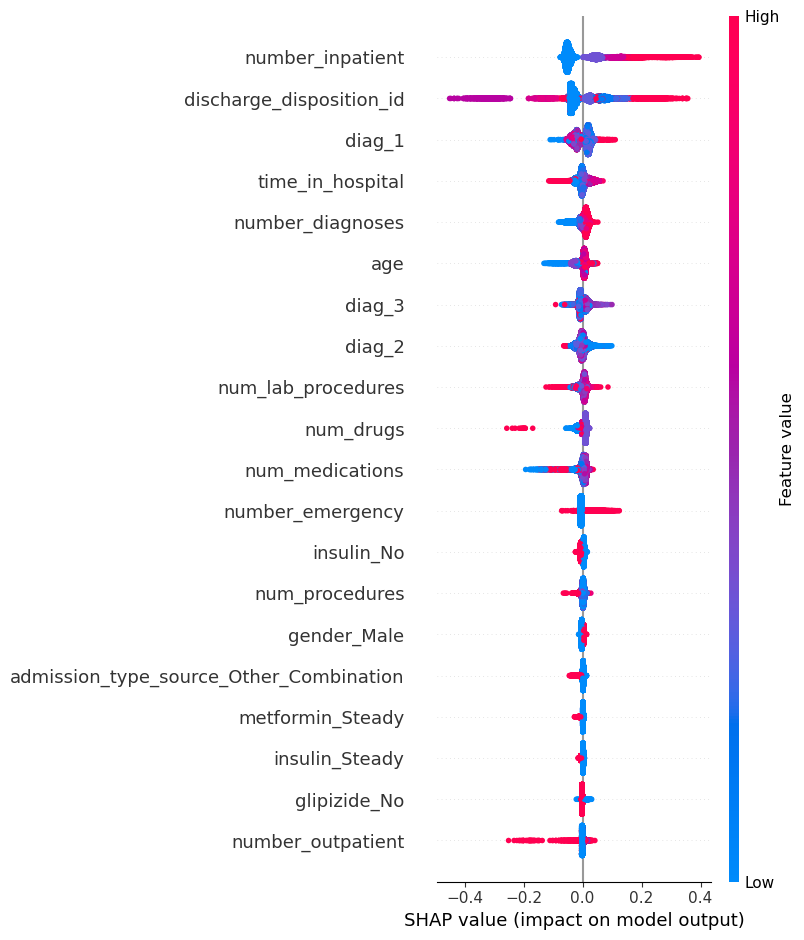

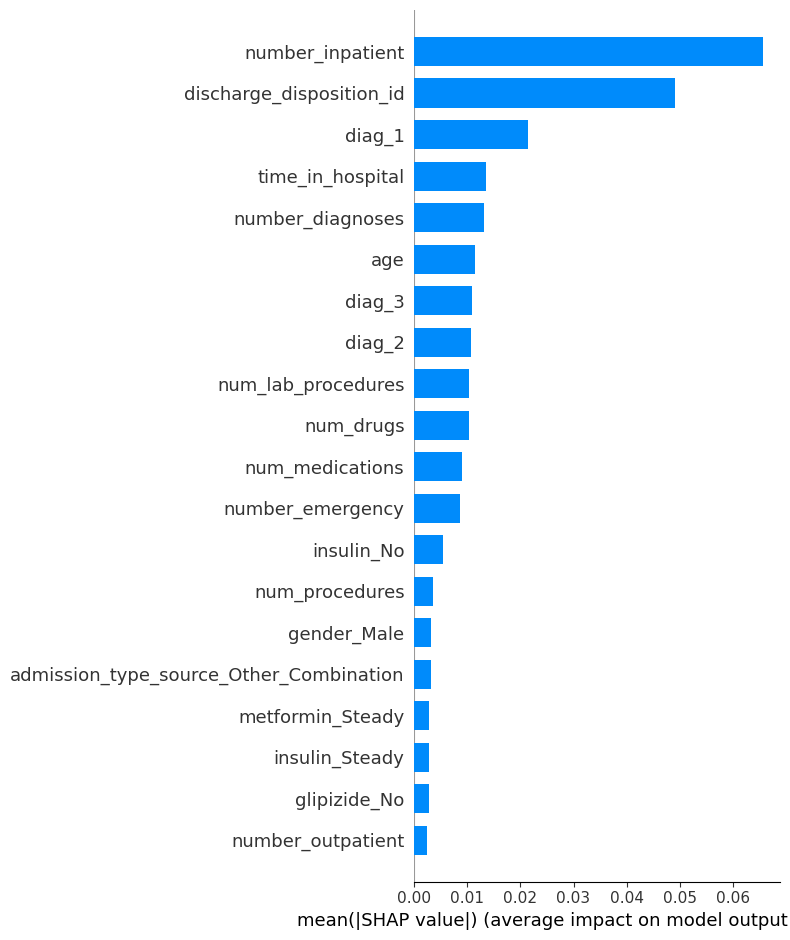

In [59]:
import shap

# 1) pull the fitted classifier from your GridSearch pipeline
#    (this assumes you kept the variables from the earlier cell)
xgb_w = gs_xgb_w.best_estimator_
xgb_w_clf = xgb_w.named_steps['clf']  # the XGBClassifier itself

# 2) build numeric background & eval matrices with the **same columns & order** as training
def numeric_matrix(df_like, feature_names):
    # select in the model's feature order and coerce to float32 ndarray
    if hasattr(df_like, "loc"):
        X = df_like.loc[:, feature_names]
        # if any column is object, try to coerce
        if any(X.dtypes == "object"):
            X = X.apply(pd.to_numeric, errors="coerce")
    else:
        # already an array
        X = pd.DataFrame(df_like, columns=feature_names)
    # fill any NaNs that could arise from coercion (tree models handle a constant fine)
    X = X.fillna(0.0)
    return X.to_numpy(dtype=np.float32)

# figure out the exact feature names the model saw at fit
if hasattr(xgb_w_clf, "feature_names_in_"):
    feat_names = list(xgb_w_clf.feature_names_in_)
else:
    # fallback: assume current X_train columns are the training features
    feat_names = list(X_train.columns)

# small background sample for speed
bg_idx = np.random.RandomState(42).choice(len(X_train), size=min(256, len(X_train)), replace=False)
X_bg = numeric_matrix(X_train.iloc[bg_idx], feat_names)
X_ex = numeric_matrix(X_test, feat_names)   # explain the whole test set (you can slice for speed)

# 3) build explainer & compute SHAP (probabilities for binary classifier)
explainer_w = shap.TreeExplainer(xgb_w_clf, data=X_bg, model_output="probability", feature_perturbation="interventional")
# For new SHAP versions you can also do: explainer_w = shap.Explainer(xgb_w_clf, X_bg, algorithm="tree")
shap_vals_w = explainer_w.shap_values(X_ex, check_additivity=False)

# 4) plots — top-20 global importances
#    Use the same feature names for readability
plt.figure()
shap.summary_plot(shap_vals_w, features=X_ex, feature_names=feat_names, max_display=20, show=True)

plt.figure()
shap.summary_plot(shap_vals_w, features=X_ex, feature_names=feat_names, max_display=20, plot_type="bar", show=True)


100%|===================| 30502/30530 [12:07<00:00]        

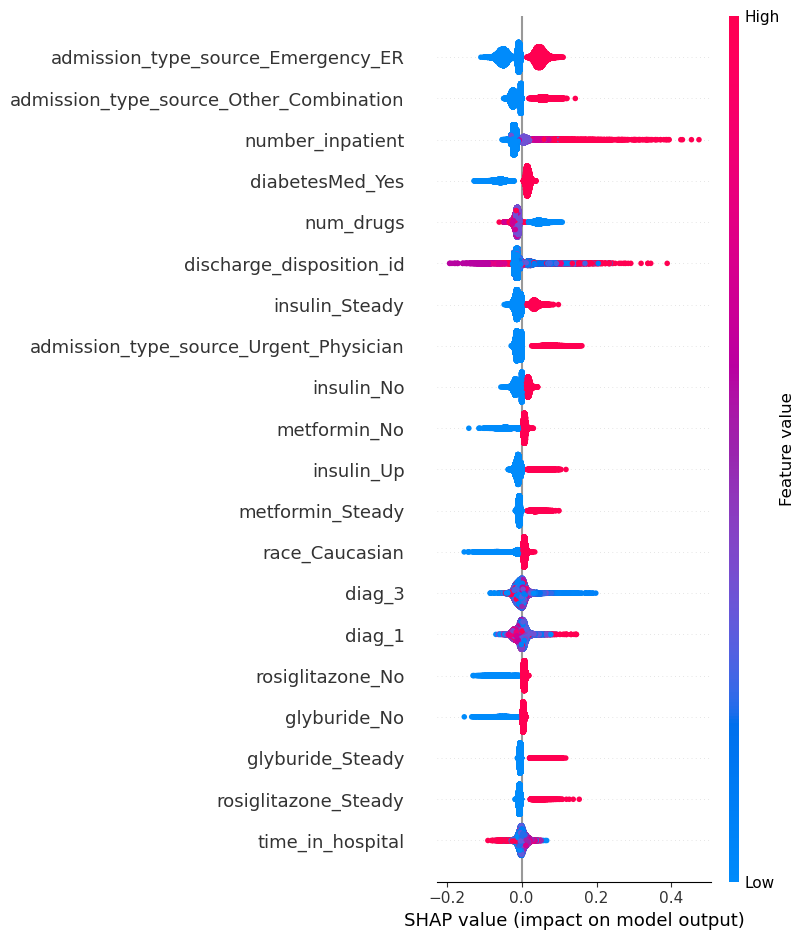

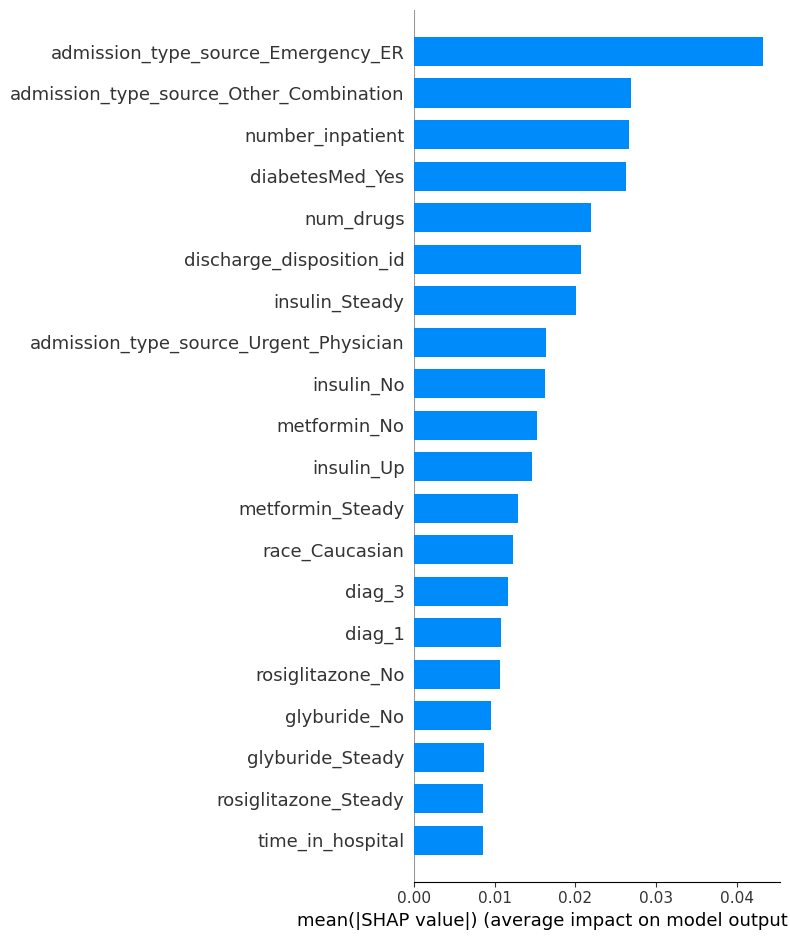

In [60]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 1) pull the fitted classifier from the SMOTE GridSearch pipeline
xgb_s = gs_xgb_smote.best_estimator_
xgb_s_clf = xgb_s.named_steps['clf']  # the XGBClassifier itself

# 2) build numeric background & eval matrices with the **same columns & order** as training
def numeric_matrix(df_like, feature_names):
    if hasattr(df_like, "loc"):
        X = df_like.loc[:, feature_names]
        if any(X.dtypes == "object"):
            X = X.apply(pd.to_numeric, errors="coerce")
    else:
        X = pd.DataFrame(df_like, columns=feature_names)
    X = X.fillna(0.0)
    return X.to_numpy(dtype=np.float32)

if hasattr(xgb_s_clf, "feature_names_in_"):
    feat_names = list(xgb_s_clf.feature_names_in_)
else:
    feat_names = list(X_train.columns)

bg_idx = np.random.RandomState(42).choice(len(X_train), size=min(256, len(X_train)), replace=False)
X_bg = numeric_matrix(X_train.iloc[bg_idx], feat_names)
X_ex = numeric_matrix(X_test, feat_names)

# 3) explainer & SHAP values
explainer_s = shap.TreeExplainer(xgb_s_clf, data=X_bg, model_output="probability", feature_perturbation="interventional")
shap_vals_s = explainer_s.shap_values(X_ex, check_additivity=False)

# 4) plots — top-20 global importances
plt.figure()
shap.summary_plot(shap_vals_s, features=X_ex, feature_names=feat_names, max_display=20, show=True)

plt.figure()
shap.summary_plot(shap_vals_s, features=X_ex, feature_names=feat_names, max_display=20, plot_type="bar", show=True)